# AI Incident Response — GRPO Training

Train two LLM agents in a competitive cybersecurity duel using **GRPO** (Group Relative Policy Optimization):

- **Attacker (red team)** — picks one attack each turn: `ATTACK: <PHISH|BRUTEFORCE|DRIVEBY|RANSOM|SQLI|RCE|LPE|SUPPLYCHAIN>`
- **Defender (blue team)** — picks one defense in response: `DEFEND: <MFA|PATCH|EDR|BACKUP|WAF|LEASTPRIV|SBOM|ROTATEKEYS>`

Each episode is 3 steps. Successful breaches reduce system health and unlock follow-on attacks. Both agents see a rolling memory of the opponent's recent moves — this drives opponent-modeling and strategic adaptation.

Training uses phase-alternating GRPO: train attacker, refresh prompts from updated attacker, train defender.

## 1. Configure Hyperparameters

In [ ]:
import time
NB_START_TIME = time.time()

TRAIN_MODEL = "qwen-0.5b"                    

MAX_STEPS          = 400                       
ATTACKER_STEPS     = 400                        
PHASE_ALTERNATIONS = 1                                              

NUM_GENERATIONS    = 4
LEARNING_RATE      = 3e-6
BATCH_SIZE         = 1
GRAD_ACCUMULATION  = 2
MAX_COMPLETION_LEN = 32                                    

SEED_EPISODES      = 256                                  
REFRESH_EPISODES   = 256                                    

GROQ_API_KEY = ""                      
GROQ_MODEL   = "llama-3.1-8b-instant"
JUDGE_PROB   = 0.0
WANDB_API_KEY = "<REMOVED>"                                       
WANDB_PROJECT = "IR-grpo"
WANDB_RUN_NAME = "Run1-grpo"
EVAL_EPISODES  = 50

HF_TOKEN    = "<REMOVED>"                                             

MODEL_REGISTRY = {
    "qwen-0.5b": "unsloth/Qwen2.5-0.5B-Instruct",
    "llama-1b":  "unsloth/Llama-3.2-1B-Instruct",
    "qwen-1.5b": "unsloth/Qwen2.5-1.5B-Instruct"
}

TRAIN_MODEL_ID = MODEL_REGISTRY[TRAIN_MODEL]
BASELINE_MODEL = TRAIN_MODEL_ID

print(f"Training model: {TRAIN_MODEL_ID}")
print(f"GRPO steps: attacker={ATTACKER_STEPS}, defender={MAX_STEPS}")
print(f"Groq judge enabled: {bool(GROQ_API_KEY)} | prob={JUDGE_PROB}")

Training model: unsloth/Qwen2.5-0.5B-Instruct
GRPO steps: attacker=400, defender=400
Groq judge enabled: False | prob=0.0


## 2. Install Dependencies

In [ ]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

!pip install --upgrade -qqq uv

try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
except: _numpy = "numpy"; _pil = "pillow"

try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
except: is_t4 = False

_vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
!uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} bitsandbytes xformers unsloth
!uv pip install -qqq {_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2      # --no-deps is critical: skips mergekit entirely
!uv pip install -qqq matplotlib numpy datasets groq wandb
!pip uninstall -y torchcodec 2>/dev/null; echo "torchcodec removed"

## 3. Experiment Tracking

In [ ]:
import os
import wandb

os.environ["WANDB_API_KEY"] = WANDB_API_KEY
wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "model": TRAIN_MODEL,
        "max_steps": MAX_STEPS,
        "attacker_steps": ATTACKER_STEPS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "grad_accumulation": GRAD_ACCUMULATION,
        "num_generations": NUM_GENERATIONS,
        "seed_episodes": SEED_EPISODES,
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gurmann-ajmani to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run 0xuagwep
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260426_062245-0xuagwep
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Run1-grpo
wandb: ⭐️ View project at https://wandb.ai/gurmann-ajmani/IR-grpo
wandb:  View run at https://wandb.ai/gurmann-ajmani/IR-grpo/runs/0xuagwep


## 4. Environment — Attacker vs Defender Duel

Defines scenarios, attack chains, health mechanics, memory summaries, and role-specific prompts.

In [ ]:
import random
import re
from collections import Counter, deque

ATTACKS  = [
    "PHISH", "BRUTEFORCE", "DRIVEBY", "RANSOM",
    "SQLI",  "RCE",        "LPE",     "SUPPLYCHAIN",
]
DEFENSES = [
    "MFA", "PATCH", "EDR", "BACKUP",
    "WAF", "LEASTPRIV", "SBOM", "ROTATEKEYS",
]

EPISODE_STEPS = 3                      

ATTACK_CHAINS = {
    "PHISH":      ["LPE", "RANSOM"],                                                              
    "BRUTEFORCE": ["RANSOM", "DRIVEBY"],                                          
    "DRIVEBY":    ["RCE", "LPE"],                                                          
    "SQLI":       ["RCE", "LPE"],                                         
    "RCE":        ["RANSOM", "SUPPLYCHAIN"],
    "LPE":        ["RANSOM", "SUPPLYCHAIN"],
    "RANSOM":     [],
    "SUPPLYCHAIN":[],
}

SCENARIOS = [
    {
        "id": "bulk_phish",
        "weakness": "PHISH",
        "hint": "Log: bulk phishing campaign detected, no clicks yet.",
        "profile": "Org: 500 users, MFA=available",
        "counter": "MFA",
    },
    {
        "id": "exec_phish",
        "weakness": "PHISH",
        "hint": "Log: CFO clicked spear-phish link, credential harvester active.",
        "profile": "Target: executive, EDR=installed, MFA=bypassed",
        "counter": "EDR",
    },
    {
        "id": "ssh_brute",
        "weakness": "BRUTEFORCE",
        "hint": "Log: many failed SSH logins from one IP, then a success.",
        "profile": "Service: ssh, rate_limits=off, MFA=available",
        "counter": "MFA",
    },
    {
        "id": "api_brute",
        "weakness": "BRUTEFORCE",
        "hint": "Log: API key rotation overdue, brute-force on API gateway.",
        "profile": "Service: REST API, MFA=not_applicable, keys=stale",
        "counter": "ROTATEKEYS",
    },
    {
        "id": "unpatched_browser",
        "weakness": "DRIVEBY",
        "hint": "Log: drive-by ad redirect chain observed on endpoints.",
        "profile": "Endpoints: outdated browser, EDR=absent",
        "counter": "PATCH",
    },
    {
        "id": "driveby_edr",
        "weakness": "DRIVEBY",
        "hint": "Log: drive-by payload dropped, C2 beacon attempting to run.",
        "profile": "Endpoints: browser patched, EDR=installed",
        "counter": "EDR",
    },
    {
        "id": "backup_gap",
        "weakness": "RANSOM",
        "hint": "Log: backups failed 3 days in a row, encryption starting.",
        "profile": "Backups: not tested, EDR=absent",
        "counter": "BACKUP",
    },
    {
        "id": "ransom_edr",
        "weakness": "RANSOM",
        "hint": "Log: ransomware binary detected in staging, not yet executed.",
        "profile": "Backups: healthy, EDR=installed",
        "counter": "EDR",
    },
]

def get_counter(sc: dict) -> str:
    return sc.get("counter", COUNTER_FALLBACK.get(sc["weakness"], "PATCH"))

COUNTER_FALLBACK = {
    "PHISH": "MFA",   "BRUTEFORCE": "MFA",  "DRIVEBY": "PATCH",
    "RANSOM": "BACKUP", "SQLI": "WAF",      "RCE": "PATCH",
    "LPE": "LEASTPRIV", "SUPPLYCHAIN": "SBOM",
}

MEMORY_WINDOW   = 10
recent_attacks  = deque(maxlen=MEMORY_WINDOW)
recent_defenses = deque(maxlen=MEMORY_WINDOW)
recent_breaches = deque(maxlen=MEMORY_WINDOW)

def _summary(prefix: str, items, universe):
    c     = Counter(items)
    parts = [f"{u}={c.get(u, 0)}" for u in universe]
    return f"{prefix}({len(items)}): " + " ".join(parts)

def attacker_memory_line():
    return _summary("Defender_recent", list(recent_defenses), DEFENSES)

def defender_memory_lines():
    return (
        _summary("Attacker_recent", list(recent_attacks),  ATTACKS)
        + "\n"
        + _summary("Recent_breaches", list(recent_breaches), ATTACKS)
    )

class EpisodeState:
    """Tracks health and history within a 3-step episode.
    Passed through prompt so Defender sees consequences of prior steps."""
    def __init__(self, sc):
        self.sc         = sc
        self.health     = 1.0
        self.step       = 0
        self.history    = []                                         
        self.unlocked   = []                                                  

    def status(self):
        if self.health >= 0.8:   return "STABLE"
        if self.health >= 0.5:   return "DEGRADED"
        return "CRITICAL"

    def apply(self, attack, defense, breached):
        if breached:
            damage = {"RANSOM": 0.4, "RCE": 0.35, "SUPPLYCHAIN": 0.35,
                      "LPE": 0.25, "DRIVEBY": 0.25, "SQLI": 0.20,
                      "PHISH": 0.15, "BRUTEFORCE": 0.15}.get(attack, 0.2)
            self.health = max(0.0, self.health - damage)
            for follow in ATTACK_CHAINS.get(attack, []):
                if follow not in self.unlocked:
                    self.unlocked.append(follow)
        self.history.append((attack, defense, breached))
        self.step += 1

    def history_str(self):
        if not self.history:
            return "No prior steps."
        lines = []
        for i, (atk, df, br) in enumerate(self.history):
            outcome = "BREACHED " if br else "BLOCKED "
            lines.append(f"  Step {i+1}: Attack={atk} | Defense={df} | {outcome}")
        return "\n".join(lines)

class DuelEnv:
    def sample_scenario(self):
        return random.choice(SCENARIOS)

    def new_episode(self, sc):
        return EpisodeState(sc)

    def attacker_prompt(self, sc, ep: EpisodeState, defender_mem_line: str):
        unlocked_str = ""
        if ep.unlocked:
            unlocked_str = f"Unlocked follow-on attacks (from prior breach): {', '.join(ep.unlocked)}\n"
        return (
            "[RED TEAM VS BLUE TEAM — MULTI-STEP DUEL]\n"
            f"Scenario: {sc['id']} | Step: {ep.step + 1}/{EPISODE_STEPS}\n"
            f"System health: {ep.health:.0%} ({ep.status()})\n"
            f"{sc['profile']}\n"
            f"{sc['hint']}\n"
            f"{ep.history_str()}\n"
            f"{unlocked_str}"
            f"{defender_mem_line}\n\n"
            "[ROLE] You are the Attacker (RED).\n"
            "Study the health, history, and profile — adapt your attack.\n"
            "Choose exactly one attack.\n"
            f"Valid attacks: {', '.join(ATTACKS)}\n\n"
            "Format exactly (one line):\n"
            "ATTACK: <" + "|".join(ATTACKS) + ">"
        )

    def defender_prompt(self, sc, ep: EpisodeState, attacker_move: str,
                        attacker_mem_lines: str):
        return (
            "[RED TEAM VS BLUE TEAM — MULTI-STEP DUEL]\n"
            f"Scenario: {sc['id']} | Step: {ep.step + 1}/{EPISODE_STEPS}\n"
            f"System health: {ep.health:.0%} ({ep.status()})\n"
            f"{sc['profile']}\n"
            f"{sc['hint']}\n"
            f"{ep.history_str()}\n"
            f"{attacker_mem_lines}\n"
            f"Attacker chose: {attacker_move}\n\n"
            "[ROLE] You are the Defender (BLUE).\n"
            "Read the health, history, and profile — adapt your defense.\n"
            "If health is DEGRADED/CRITICAL, prioritize recovery defenses.\n"
            "Choose exactly one defense.\n"
            f"Valid defenses: {', '.join(DEFENSES)}\n\n"
            "Format exactly (one line):\n"
            "DEFEND: <" + "|".join(DEFENSES) + ">"
        )

ENV = DuelEnv()

## 5. Load Base Model

In [ ]:
import torch
from unsloth import FastModel

MAX_SEQ_LENGTH = 512

 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-04-26 06:23:04.032334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777184584.416875      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777184584.514437      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777184585.448130      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184585.448170      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184585.448173      23 computation_placer.cc:177] computation placer alr

INFO 04-26 06:23:48 [__init__.py:244] Automatically detected platform cuda.
ERROR 04-26 06:23:52 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
 Unsloth Zoo will now patch everything to make training faster!


## 6. Reward Functions and Prompt Dataset

Dense per-step rewards with format penalty, partial-credit proxy, and optional LLM judge blend.

In [ ]:
from datasets import Dataset
from groq import Groq as GroqClient
import re
import json
import random
from pathlib import Path

OUTPUT_DIR = Path("outputs/grpo_training")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

attack_re = re.compile(
    r"ATTACK:\s*(PHISH|BRUTEFORCE|DRIVEBY|RANSOM|SQLI|RCE|LPE|SUPPLYCHAIN)\b",
    re.IGNORECASE)
defend_re = re.compile(
    r"DEFEND:\s*(MFA|PATCH|EDR|BACKUP|WAF|LEASTPRIV|SBOM|ROTATEKEYS)\b",
    re.IGNORECASE)

def parse_attack(text: str):
    m = attack_re.search(text or "")
    return (m.group(1).upper() if m else "")

def parse_defense(text: str):
    m = defend_re.search(text or "")
    return (m.group(1).upper() if m else "")

def parse_scenario_and_attack_from_prompt(prompt: str):
    sc_id = ""
    m = re.search(r"Scenario:\s*(\w+)", prompt)
    if m:
        sc_id = m.group(1)
    atk = ""
    m2 = re.search(r"Attacker chose:\s*(\w+)", prompt)
    if m2:
        atk = m2.group(1).upper()
    sc = next((s for s in SCENARIOS if s["id"] == sc_id), None)
    return sc, atk

def outcome_breached(sc, attacker_move: str, defender_move: str,
                     ep: "EpisodeState" = None) -> bool:
    """Breached if:
    1. Attack hits the weakness AND defender chose wrong, OR
    2. Attack is a follow-on (unlocked) attack AND any defense fails to counter it
    """
    if not sc:
        return False
    is_weakness    = (attacker_move == sc["weakness"])
    is_followon    = (ep is not None) and (attacker_move in ep.unlocked)
    if not is_weakness and not is_followon:
        return False
    if is_followon and not is_weakness:
        correct = COUNTER_FALLBACK.get(attacker_move, "PATCH")
    else:
        correct = get_counter(sc)
    return defender_move != correct

FORMAT_PENALTY = -1.0
PARTIAL_CREDIT_PROXY = {
    ("PHISH",      "EDR"):        0.40,
    ("PHISH",      "PATCH"):      0.10,
    ("PHISH",      "BACKUP"):     0.05,
    ("BRUTEFORCE", "PATCH"):      0.18,
    ("BRUTEFORCE", "EDR"):        0.25,
    ("BRUTEFORCE", "WAF"):        0.30,
    ("DRIVEBY",    "EDR"):        0.62,
    ("DRIVEBY",    "MFA"):        0.05,
    ("RANSOM",     "EDR"):        0.55,
    ("RANSOM",     "PATCH"):      0.15,
    ("SQLI",       "PATCH"):      0.40,
    ("RCE",        "EDR"):        0.60,
    ("LPE",        "PATCH"):      0.45,
    ("SUPPLYCHAIN","PATCH"):      0.35,
}

def p_block(atk: str, df: str) -> float:
    return PARTIAL_CREDIT_PROXY.get((atk, df), 0.05)
_groq = GroqClient(api_key=GROQ_API_KEY) if GROQ_API_KEY else None

JUDGE_SYSTEM = "You are a cybersecurity training evaluator. Return JSON only, no markdown."

DEFENDER_JUDGE_TMPL = """A defender chose a defense in a security scenario.

Scenario profile: {profile}
Log hint: {hint}
Attacker chose: {attack}
Defender chose: {defense}
Correct defense for this scenario: {correct}

Score the defender's choice considering the profile context.
Rules:
- score=1.0 only if defense matches the correct defense AND fits the profile
- score=0.3 to 0.6 if defense is partially useful given the profile
- score=-0.5 to -1.0 if defense ignores the profile entirely or is irrelevant

Return JSON only: {{"score": <-1.0 to 1.0>, "correct": <bool>, "reason": "<one sentence>"}}"""

ATTACKER_JUDGE_TMPL = """An attacker chose an attack in a security scenario.

Scenario profile: {profile}
Log hint: {hint}
Attacker chose: {attack}
Scenario weakness: {weakness}

Rules:
- score=1.0 if attack matches weakness AND is clearly justified by the profile/hint
- score=0.2 if attack matches weakness but ignores profile context
- score=-0.5 if attack is wrong but hint was genuinely ambiguous
- score=-1.0 if attack is completely wrong given obvious profile signals

Return JSON only: {{"score": <-1.0 to 1.0>, "correct": <bool>, "reason": "<one sentence>"}}"""

def _call_groq_judge(tmpl_str: str) -> float | None:
    """Call Groq judge, return float score or None on any failure."""
    if not _groq:
        return None
    try:
        resp = _groq.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": JUDGE_SYSTEM},
                {"role": "user",   "content": tmpl_str}
            ],
            temperature=0.1,
            max_tokens=120,
        )
        raw = resp.choices[0].message.content.strip()
        if raw.startswith("```"):
            raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
        data = json.loads(raw)
        return float(data.get("score", 0.0))
    except Exception:
        return None

def llm_judge_defender(sc, atk, df) -> float | None:
    return _call_groq_judge(DEFENDER_JUDGE_TMPL.format(
        profile=sc["profile"], hint=sc["hint"],
        attack=atk, defense=df, correct=get_counter(sc)))

def llm_judge_attacker(sc, atk) -> float | None:
    return _call_groq_judge(ATTACKER_JUDGE_TMPL.format(
        profile=sc["profile"], hint=sc["hint"],
        attack=atk, weakness=sc["weakness"]))
def attacker_reward_func(prompts, completions, **kwargs):
    """Attacker reward: summed over episode steps with discount.
    Step 1 breach → +1.0. Follow-on breach (step 2-3) → +0.8 (slightly discounted).
    Unlocking a follow-on attack even without breach → +0.2 (partial credit).
    """
    rewards = []
    for prompt, completion in zip(prompts, completions):
        text = completion[0]["content"] if isinstance(completion, list) else completion
        atk  = parse_attack(text)
        sc, _ = parse_scenario_and_attack_from_prompt(prompt)

        if not atk or atk not in ATTACKS or not sc:
            rewards.append(FORMAT_PENALTY)
            continue

        ep = _parse_episode_from_prompt(prompt)

        is_weakness  = (atk == sc["weakness"])
        is_followon  = (atk in ep.unlocked) if ep else False
        step_discount = 1.0 if (ep is None or ep.step == 0) else 0.8

        if is_weakness or is_followon:
            base_reward = 1.0 * step_discount
        elif ep and ep.unlocked:
            base_reward = -0.3
        else:
            base_reward = -0.2

        if GROQ_API_KEY and random.random() < JUDGE_PROB:
            judge_score = llm_judge_attacker(sc, atk)
            reward = (0.7 * base_reward + 0.3 * judge_score
                      if judge_score is not None else base_reward)
        else:
            reward = base_reward

        rewards.append(reward)
    return rewards

def defender_reward_func(prompts, completions, **kwargs):
    """Defender reward: summed over episode steps with health bonus.
    Correct defense → +1.0.
    Correct defense when health DEGRADED/CRITICAL → +1.3 (recovery bonus).
    Wrong defense → partial credit via p_block proxy or -0.8.
    Health preservation bonus: +health * 0.3 (rewards keeping system alive).
    """
    rewards = []
    for prompt, completion in zip(prompts, completions):
        text = completion[0]["content"] if isinstance(completion, list) else completion
        df   = parse_defense(text)
        sc, atk = parse_scenario_and_attack_from_prompt(prompt)

        if not df or df not in DEFENSES or not sc:
            rewards.append(FORMAT_PENALTY)
            continue
        if atk not in ATTACKS:
            atk = sc["weakness"] if sc else ""
        if not atk:
            rewards.append(FORMAT_PENALTY)
            continue

        ep      = _parse_episode_from_prompt(prompt)
        health  = ep.health if ep else 1.0
        status  = ep.status() if ep else "STABLE"
        correct = get_counter(sc)

        if df == correct:
            recovery_bonus = 0.3 if status in ("DEGRADED", "CRITICAL") else 0.0
            base_reward    = 1.0 + recovery_bonus
        elif df in DEFENSES:
            try:
                partial     = p_block(atk, df) if atk in ATTACKS else 0.1
                base_reward = (partial * 2.0) - 1.0
                base_reward = max(base_reward, -0.8)
            except:
                base_reward = -0.5
        else:
            base_reward = -1.0

        base_reward += health * 0.3

        if GROQ_API_KEY and random.random() < JUDGE_PROB:
            judge_score = llm_judge_defender(sc, atk, df)
            reward = (0.7 * base_reward + 0.3 * judge_score
                      if judge_score is not None else base_reward)
        else:
            reward = base_reward

        rewards.append(reward)
    return rewards

def _parse_episode_from_prompt(prompt: str) -> "EpisodeState":
    """Reconstruct a lightweight EpisodeState from the prompt text.
    Only needs health and unlocked attacks for reward computation."""
    sc_id = ""
    m = re.search(r"Scenario:\s*(\w+)", prompt)
    if m: sc_id = m.group(1)
    sc = next((s for s in SCENARIOS if s["id"] == sc_id), None)
    ep = EpisodeState(sc) if sc else EpisodeState(SCENARIOS[0])

    mh = re.search(r"System health:\s*([\d.]+)%", prompt)
    if mh:
        ep.health = float(mh.group(1)) / 100.0

    for line in prompt.split("\n"):
        m_breach = re.search(r"Attack=(\w+).*BREACHED", line)
        if m_breach:
            breached_atk = m_breach.group(1)
            for follow in ATTACK_CHAINS.get(breached_atk, []):
                if follow not in ep.unlocked:
                    ep.unlocked.append(follow)
    ep.step = len(ep.history)
    return ep

def make_seed_datasets(n=SEED_EPISODES):
    """Generate seed prompts that sample from across all 3 episode steps.
    40% step-1 prompts (clean state), 35% step-2 prompts (some history),
    25% step-3 prompts (degraded state) — model sees full episode distribution."""
    atk_prompts, def_prompts = [], []
    def_mem_line  = attacker_memory_line()
    atk_mem_lines = defender_memory_lines()

    for _ in range(n):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)

        prior_steps = random.choices([0, 1, 2], weights=[0.40, 0.35, 0.25])[0]
        for _ in range(prior_steps):
            atk = sc["weakness"] if random.random() < 0.6 else random.choice(ATTACKS)
            df  = get_counter(sc) if random.random() < 0.4 else random.choice(DEFENSES)
            br  = outcome_breached(sc, atk, df, ep)
            ep.apply(atk, df, br)

        atk_prompts.append({"prompt": ENV.attacker_prompt(sc, ep, def_mem_line)})

    for _ in range(n):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)

        prior_steps = random.choices([0, 1, 2], weights=[0.40, 0.35, 0.25])[0]
        for _ in range(prior_steps):
            atk = sc["weakness"] if random.random() < 0.6 else random.choice(ATTACKS)
            df  = get_counter(sc) if random.random() < 0.4 else random.choice(DEFENSES)
            br  = outcome_breached(sc, atk, df, ep)
            ep.apply(atk, df, br)

        atk = sc["weakness"]
        def_prompts.append({"prompt": ENV.defender_prompt(sc, ep, atk, atk_mem_lines)})

    return Dataset.from_list(def_prompts), Dataset.from_list(atk_prompts)

train_dataset, attacker_dataset = make_seed_datasets(SEED_EPISODES)

## 7. GRPO Training Loop

Phase-alternating: train attacker, refresh datasets, train defender. Runs evaluation rollouts between phases.

In [ ]:
import torch
from pathlib import Path
from transformers import TrainerCallback
from unsloth import FastModel
from trl import GRPOConfig, GRPOTrainer

class CLIProgressCallback(TrainerCallback):
    def __init__(self, tag: str, rolling=10):
        self.tag = tag
        self.rolling = rolling
        self._recent = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        step   = state.global_step
        reward = logs.get("reward", logs.get("train/reward", None))
        if isinstance(reward, (int, float)):
            self._recent.append(float(reward))
            if len(self._recent) > self.rolling:
                self._recent = self._recent[-self.rolling:]
            mean_r = sum(self._recent) / len(self._recent)
            print(f"  [{self.tag}] step={step:3d} | reward={reward:+.4f} | "
                  f"mean(last{len(self._recent)}): {mean_r:+.4f}")
        elif reward is not None:
            print(f"  [{self.tag}] step={step:3d} | reward={reward}")

def _extract_rewards(log_history):
    steps, rewards = [], []
    for entry in log_history:
        s = entry.get("step")
        if not s:
            continue
        r = entry.get("reward", entry.get("train/reward", float("nan")))
        steps.append(s)
        rewards.append(r)
    return steps, rewards

def _make_lora(base_model_id):
    mdl, _ = FastModel.from_pretrained(
        model_name=base_model_id,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
    )
    return FastModel.get_peft_model(
        mdl,
        r=16,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
    )

def _grpo_config(output_dir, max_steps):
    return GRPOConfig(
        learning_rate=LEARNING_RATE,
        max_prompt_length=512,                                                     
        max_completion_length=MAX_COMPLETION_LEN,
        num_generations=NUM_GENERATIONS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUMULATION,
        max_steps=max_steps,
        beta=0.04,                                                          
        logging_steps=1,
        output_dir=str(output_dir),
        report_to="wandb"
    )

@torch.no_grad()
def sample_actions(model, tok, prompts, max_new_tokens=MAX_COMPLETION_LEN, temperature=0.4):
    FastModel.for_inference(model)
    outs = []
    for p in prompts:
        inputs = tok(
            p, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH
        ).to(model.device)
        gen = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tok.eos_token_id,
        )
        text = tok.decode(gen[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        outs.append(text)
    return outs

@torch.no_grad()
def rollout_duels(attacker_ckpt, defender_ckpt, n=30, verbose=3, update_memory=True):
    """Runs EPISODE_STEPS-step episodes. Tracks breach rate, health, and
    attack chain activations across each episode."""
    atk_m, atk_t = FastModel.from_pretrained(
        model_name=attacker_ckpt, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)
    df_m,  df_t  = FastModel.from_pretrained(
        model_name=defender_ckpt, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)

    total_breaches    = 0
    chain_activations = 0
    shown             = 0

    for i in range(n):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)
        episode_breached = False

        if shown < verbose:
            print(f"\n--- Episode {i+1} | scenario={sc['id']} | weakness={sc['weakness']} ---")

        for step_i in range(EPISODE_STEPS):
            atk_prompt = ENV.attacker_prompt(sc, ep, attacker_memory_line())
            atk_out    = sample_actions(atk_m, atk_t, [atk_prompt])[0]
            atk        = parse_attack(atk_out)
            if atk not in ATTACKS:
                atk = ""

            df_prompt = ENV.defender_prompt(
                sc, ep, atk or "UNKNOWN", defender_memory_lines())
            df_out    = sample_actions(df_m, df_t, [df_prompt])[0]
            df        = parse_defense(df_out)
            if df not in DEFENSES:
                df = ""

            breached = False
            if atk in ATTACKS and df in DEFENSES:
                breached = outcome_breached(sc, atk, df, ep)
            elif atk in ATTACKS and df not in DEFENSES:
                breached = (atk == sc["weakness"]) or (atk in ep.unlocked)

            ep.apply(atk, df, breached)

            if breached:
                episode_breached = True
            if ep.unlocked:
                chain_activations += 1

            if update_memory:
                if atk in ATTACKS:
                    recent_attacks.append(atk)
                if df in DEFENSES:
                    recent_defenses.append(df)
                if breached and atk in ATTACKS:
                    recent_breaches.append(atk)

            if shown < verbose:
                outcome_str = "BREACHED " if breached else "BLOCKED "
                print(f"  Step {step_i+1}: Atk={atk or '(INVALID)':12s} | "
                      f"Def={df or '(INVALID)':12s} | {outcome_str} | "
                      f"Health={ep.health:.0%} | Chains={ep.unlocked}")

        total_breaches += int(episode_breached)
        if shown < verbose:
            print(f"  → Final health: {ep.health:.0%} ({ep.status()})")
            shown += 1

    atk_m.cpu(); df_m.cpu()
    del atk_m, df_m
    torch.cuda.empty_cache()

    return {
        "breach_rate":       total_breaches / max(1, n),
        "breaches":          total_breaches,
        "n":                 n,
        "chain_activations": chain_activations,
    }

training_results  = {}
def_out           = OUTPUT_DIR / "defender"
atk_out           = OUTPUT_DIR / "attacker"

all_def_steps,  all_def_rewards  = [], []
all_atk_steps,  all_atk_rewards  = [], []
step_offset_def, step_offset_atk = 0, 0

for phase in range(PHASE_ALTERNATIONS):
    print(f"\n── Phase {phase+1}/{PHASE_ALTERNATIONS} ──")

    print("Warming rolling memory (baseline multi-step duels)...")
    _ = rollout_duels(
        attacker_ckpt=TRAIN_MODEL_ID,
        defender_ckpt=TRAIN_MODEL_ID,
        n=20, verbose=0, update_memory=True)

    print(f"Training Attacker ({ATTACKER_STEPS} steps)...")
    atk_start = (str(atk_out)
                 if phase > 0 and (atk_out / "config.json").exists()
                 else TRAIN_MODEL_ID)
    atk_model   = _make_lora(atk_start)
    atk_trainer = GRPOTrainer(
        model=atk_model,
        reward_funcs=attacker_reward_func,
        args=_grpo_config(atk_out, ATTACKER_STEPS),
        train_dataset=attacker_dataset,
        callbacks=[CLIProgressCallback("ATTACK")],
    )
    atk_trainer.train()
    atk_trainer.save_model(str(atk_out))
    s, r = _extract_rewards(atk_trainer.state.log_history)
    all_atk_steps  += [x + step_offset_atk for x in s]
    all_atk_rewards += r
    step_offset_atk += ATTACKER_STEPS
    del atk_model, atk_trainer
    torch.cuda.empty_cache()

    print(f"Refreshing datasets ({REFRESH_EPISODES} episodes x {EPISODE_STEPS} steps)...")

    atk_inf, atk_tok = FastModel.from_pretrained(
        model_name=str(atk_out), max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)

    refreshed_atk_prompts = []
    refreshed_def_prompts = []

    for _ in range(REFRESH_EPISODES):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)

        for step_i in range(EPISODE_STEPS):
            atk_prompt = ENV.attacker_prompt(sc, ep, attacker_memory_line())
            atk_out_r  = sample_actions(atk_inf, atk_tok, [atk_prompt], temperature=0.4)[0]
            atk        = parse_attack(atk_out_r)
            if atk not in ATTACKS:
                atk = random.choice(ATTACKS)

            refreshed_atk_prompts.append({"prompt": atk_prompt})
            refreshed_def_prompts.append({
                "prompt": ENV.defender_prompt(sc, ep, atk, defender_memory_lines())
            })

            df_sim   = (get_counter(sc)
                        if random.random() < 0.5
                        else random.choice(DEFENSES))
            breached = outcome_breached(sc, atk, df_sim, ep)
            ep.apply(atk, df_sim, breached)

            if atk in ATTACKS:    recent_attacks.append(atk)
            if df_sim in DEFENSES: recent_defenses.append(df_sim)
            if breached:          recent_breaches.append(atk)

    del atk_inf
    torch.cuda.empty_cache()

    total_refresh = len(refreshed_atk_prompts)
    print(f"   ↳ Refreshed {total_refresh} attacker + {len(refreshed_def_prompts)} defender prompts")
    print(f"   ↳ Memory state: attacks={len(recent_attacks)} "
          f"defenses={len(recent_defenses)} breaches={len(recent_breaches)}")

    attacker_dataset = Dataset.from_list(
        (refreshed_atk_prompts
         + [{"prompt": p["prompt"]} for p in attacker_dataset.select(
             range(min(len(attacker_dataset),
                       SEED_EPISODES - len(refreshed_atk_prompts))))]
         )[:SEED_EPISODES])

    train_dataset = Dataset.from_list(
        (refreshed_def_prompts
         + [{"prompt": p["prompt"]} for p in train_dataset.select(
             range(min(len(train_dataset),
                       SEED_EPISODES - len(refreshed_def_prompts))))]
         )[:SEED_EPISODES])

    print(f"Datasets: attacker={len(attacker_dataset)} defender={len(train_dataset)}")

    print(f"Training Defender ({MAX_STEPS} steps)...")
    def_start = (str(def_out)
                 if phase > 0 and (def_out / "config.json").exists()
                 else TRAIN_MODEL_ID)
    def_model   = _make_lora(def_start)
    def_trainer = GRPOTrainer(
        model=def_model,
        reward_funcs=defender_reward_func,
        args=_grpo_config(def_out, MAX_STEPS),
        train_dataset=train_dataset,
        callbacks=[CLIProgressCallback("DEFEND")],
    )
    def_trainer.train()
    def_trainer.save_model(str(def_out))
    s, r = _extract_rewards(def_trainer.state.log_history)
    all_def_steps  += [x + step_offset_def for x in s]
    all_def_rewards += r
    step_offset_def += MAX_STEPS
    del def_model, def_trainer
    torch.cuda.empty_cache()

    print("\nQuick rollout (trained attacker vs trained defender):")
    stats = rollout_duels(
        attacker_ckpt=str(atk_out),
        defender_ckpt=str(def_out),
        n=25, verbose=3, update_memory=True)
    print(f"Breach rate: {stats['breach_rate']:.2%} "
          f"({stats['breaches']}/{stats['n']}) | "
          f"Chain activations: {stats['chain_activations']}")

training_results["standard"] = {
    "steps":      all_def_steps,
    "rewards":    all_def_rewards,
    "atk_steps":  all_atk_steps,
    "atk_rewards": all_atk_rewards,
    "output_dir": def_out,
    "atk_dir":    atk_out,
}

try:
    _, base_tok = FastModel.from_pretrained(
        model_name=TRAIN_MODEL_ID, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=False)
    base_tok.save_pretrained(str(atk_out))
    base_tok.save_pretrained(str(def_out))
    print("Tokenizer saved to attacker/defender output dirs")
except Exception as e:
    print("Could not save tokenizer:", e)

print("Training complete")
print(f"Attacker checkpoint: {atk_out}")
print(f"Defender checkpoint: {def_out}")


── Phase 1/1 ──
Warming rolling memory (baseline multi-step duels)...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-0.5B-Instruct does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Tokenizer saved to attacker/defender output dirs
Training complete
Attacker checkpoint: outputs/grpo_training/attacker
Defender checkpoint: outputs/grpo_training/defender


## 8. Training Reward Curves

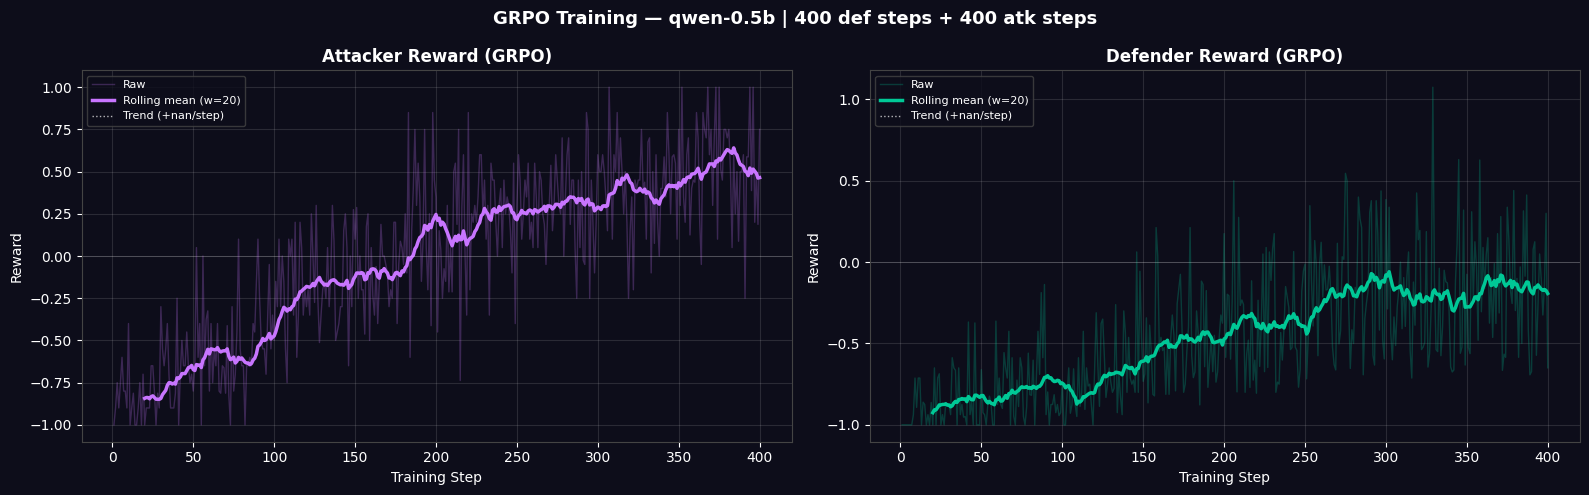

Saved training_curves.png


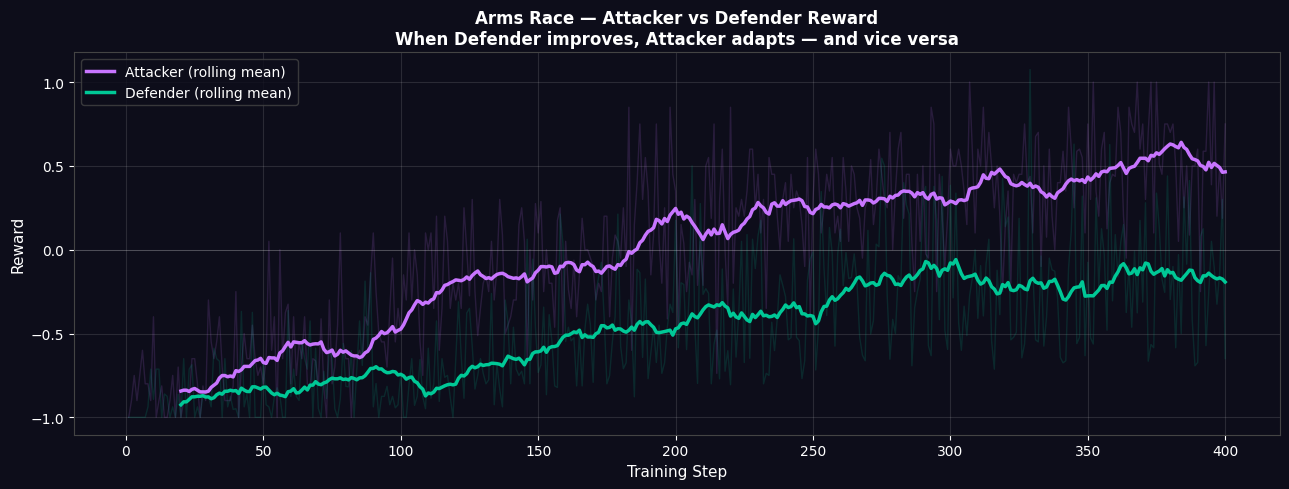

Saved arms_race.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

res = training_results["standard"]

def smooth(values, w=20):
    arr = np.asarray(values, dtype=float)
    if len(arr) < w:
        return arr
    return np.convolve(arr, np.ones(w)/w, mode="valid")

w = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#0d0d1a")
for ax in axes:
    ax.set_facecolor("#0d0d1a")
    ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_color("#444")
    ax.grid(True, alpha=0.12, color="white")

def plot_curve(ax, steps, values, title, color):
    if not steps or not values:
        return
    steps_arr  = np.array(steps)
    values_arr = np.array(values, dtype=float)
    ax.plot(steps_arr, values_arr, color=color, alpha=0.25, linewidth=1, label="Raw")
    sm = smooth(values_arr, w)
    if len(sm) > 0:
        ax.plot(steps_arr[w-1:], sm, color=color, linewidth=2.5, label=f"Rolling mean (w={w})")
    if len(steps_arr) > 2:
        z = np.polyfit(steps_arr, values_arr, 1)
        ax.plot(steps_arr, np.poly1d(z)(steps_arr), color="white",
                linestyle=":", linewidth=1, alpha=0.7, label=f"Trend ({z[0]:+.4f}/step)")
    ax.axhline(0, color="white", linewidth=0.4, alpha=0.3)
    ax.set_title(title, color="white", fontweight="bold", fontsize=12)
    ax.set_xlabel("Training Step", color="white", fontsize=10)
    ax.set_ylabel("Reward", color="white", fontsize=10)
    ax.legend(facecolor="#0d0d1a", edgecolor="#444", labelcolor="white", fontsize=8)

plot_curve(axes[0], res["atk_steps"], res["atk_rewards"], "Attacker Reward (GRPO)", "#C875FF")
plot_curve(axes[1], res["steps"],     res["rewards"],     "Defender Reward (GRPO)", "#00C896")

plt.suptitle(f"GRPO Training — {TRAIN_MODEL} | {MAX_STEPS} def steps + {ATTACKER_STEPS} atk steps",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved training_curves.png")

fig2, ax2 = plt.subplots(figsize=(13, 5))
fig2.patch.set_facecolor("#0d0d1a")
ax2.set_facecolor("#0d0d1a")
ax2.tick_params(colors="white")
for s in ax2.spines.values(): s.set_color("#444")
ax2.grid(True, alpha=0.12, color="white")

atk_arr = np.array(res["atk_rewards"], dtype=float)
def_arr = np.array(res["rewards"],     dtype=float)
atk_s   = np.array(res["atk_steps"])
def_s   = np.array(res["steps"])

ax2.plot(atk_s, atk_arr, color="#C875FF", alpha=0.15, linewidth=1)
ax2.plot(def_s, def_arr, color="#00C896", alpha=0.15, linewidth=1)

if len(atk_arr) >= w:
    ax2.plot(atk_s[w-1:], smooth(atk_arr, w), color="#C875FF",
             linewidth=2.5, label="Attacker (rolling mean)")
if len(def_arr) >= w:
    ax2.plot(def_s[w-1:], smooth(def_arr, w), color="#00C896",
             linewidth=2.5, label="Defender (rolling mean)")

ax2.axhline(0, color="white", linewidth=0.4, alpha=0.3)
ax2.set_xlabel("Training Step", color="white", fontsize=11)
ax2.set_ylabel("Reward",        color="white", fontsize=11)
ax2.set_title(
    "Arms Race — Attacker vs Defender Reward\n"
    "When Defender improves, Attacker adapts — and vice versa",
    color="white", fontsize=12, fontweight="bold")
ax2.legend(facecolor="#0d0d1a", edgecolor="#444", labelcolor="white", fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "arms_race.png", dpi=150, facecolor=fig2.get_facecolor())
plt.show()
print("Saved arms_race.png")

In [ ]:
print("Saved attacker:", training_results["standard"]["atk_dir"])
print("Saved defender:", training_results["standard"]["output_dir"])

Saved attacker: outputs/grpo_training/attacker
Saved defender: outputs/grpo_training/defender


## 9. Runtime Summary

In [ ]:
import time
elapsed_s = time.time() - NB_START_TIME
print(f"\nTotal notebook runtime: {elapsed_s/60:.2f} minutes ({elapsed_s:.1f} seconds)")
wandb.finish()


Total notebook runtime: 131.17 minutes (7870.2 seconds)


wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:    profiling/Time taken: UnslothGRPOTrainer._calculate_rewards ▂▂▂▁▃▃▂▃▂▂▃▂▃▃▃▁▂▂▁▂▁▃▂▁▄▃▃█▃▄▂▃▂▄▂▃▃▄▃▃
wandb:       profiling/Time taken: UnslothGRPOTrainer._prepare_inputs █▁█▁█▁██▁█▁▁▁▁▁▁█▁█▁███▁▁▁▁██▁███▁▁▁█▁▁█
wandb:  profiling/Time taken: UnslothGRPOTrainer.attacker_reward_func ▄▂▂▂▄▃▇▂▁▂▁▃▃▄▃▆▇▅▄▄▇▄█▆▄█▄▅▇▇▃▄▄▇▅▆▄▅▇▄
wandb:  profiling/Time taken: UnslothGRPOTrainer.defender_reward_func ▁▃▃▅▃▃▃▃▃▅▃▄▃▆▄▄▃▆▅▆▃▄▄▇▆▆▆▆▆▆▆▅▇█▇▇▅▆▅▄
wandb: profiling/Time taken: UnslothGRPOTrainer.transformers.generate █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                                      train/clip_ratio/high_max ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                                     train/clip_ratio/high_mean ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                                      train/clip_ratio/low_mean ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                                       train/clip

## 10. Before / After Behavioral Demo

Rolling-mean reward overlaid for attacker and defender to show learning trajectory.

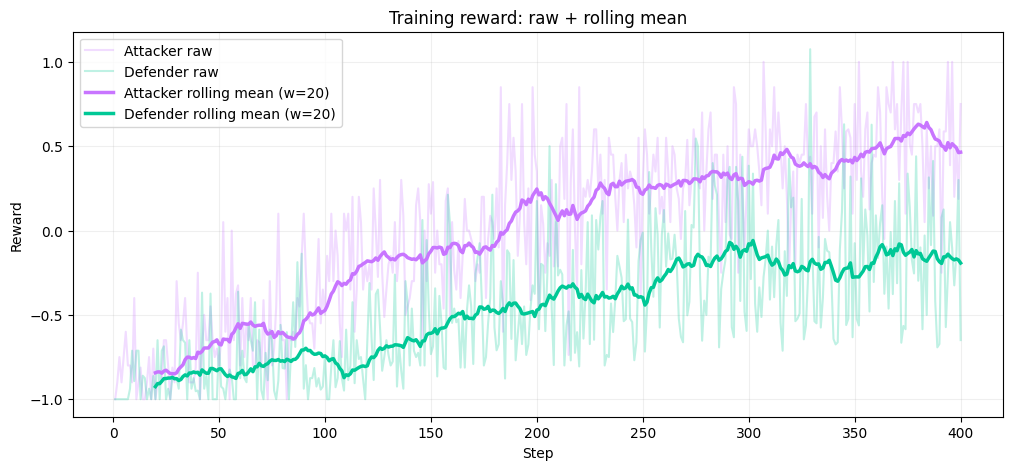

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_mean(x, w=20):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")

w = 20

atk_steps = np.array(res["atk_steps"])
atk_rewards = np.array(res["atk_rewards"])
def_steps = np.array(res["steps"])
def_rewards = np.array(res["rewards"])

atk_rm = rolling_mean(atk_rewards, w)
def_rm = rolling_mean(def_rewards, w)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(atk_steps, atk_rewards, color="#C875FF", alpha=0.25, label="Attacker raw")
ax.plot(def_steps, def_rewards, color="#00C896", alpha=0.25, label="Defender raw")

ax.plot(atk_steps[w-1:], atk_rm, color="#C875FF", linewidth=2.5, label=f"Attacker rolling mean (w={w})")
ax.plot(def_steps[w-1:], def_rm, color="#00C896", linewidth=2.5, label=f"Defender rolling mean (w={w})")

ax.set_title("Training reward: raw + rolling mean")
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.grid(True, alpha=0.2)
ax.legend()
plt.show()

## 12. Evaluation — Baseline vs Trained

Compares untrained base model vs GRPO-trained attacker and defender across 50 fixed episodes.

In [ ]:
import random
import numpy as np

EVAL_N = int(EVAL_EPISODES) if "EVAL_EPISODES" in globals() else 50
EVAL_SEED = 1234

EVAL_ATTACKER_CKPT = str(atk_out)
EVAL_DEFENDER_CKPT = str(def_out)
EVAL_BASELINE_CKPT = BASELINE_MODEL if "BASELINE_MODEL" in globals() else TRAIN_MODEL_ID

In [ ]:
from dataclasses import dataclass

@dataclass
class EvalResult:
    mean_reward: float
    std_reward: float
    max_reward: float
    format_valid_rate: float

def _to_eval_result(rewards: list[float], valid_flags: list[int]) -> EvalResult:
    r = np.asarray(rewards, dtype=float)
    v = np.asarray(valid_flags, dtype=float)
    return EvalResult(
        mean_reward=float(r.mean()) if len(r) else 0.0,
        std_reward=float(r.std(ddof=0)) if len(r) else 0.0,
        max_reward=float(r.max()) if len(r) else 0.0,
        format_valid_rate=float(v.mean()) if len(v) else 0.0,
    )

@torch.no_grad()
def eval_attacker_one_step(model_ckpt: str, n=20, seed=1234, temperature=0.4) -> EvalResult:
    random.seed(seed)
    np.random.seed(seed)

    m, tok = FastModel.from_pretrained(
        model_name=model_ckpt, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True
    )

    rewards: list[float] = []
    valid: list[int] = []

    for _ in range(n):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)
        prompt = ENV.attacker_prompt(sc, ep, attacker_memory_line())
        out = sample_actions(m, tok, [prompt], temperature=temperature)[0]
        atk = parse_attack(out)

        is_valid = int(atk in ATTACKS)
        valid.append(is_valid)

        if not is_valid:
            rewards.append(float(FORMAT_PENALTY))
        else:
            rewards.append(1.0 if atk == sc["weakness"] else -0.2)

    m.cpu(); del m
    torch.cuda.empty_cache()

    return _to_eval_result(rewards, valid)

@torch.no_grad()
def eval_defender_one_step(model_ckpt: str, n=20, seed=1234, temperature=0.4) -> EvalResult:
    random.seed(seed)
    np.random.seed(seed)

    m, tok = FastModel.from_pretrained(
        model_name=model_ckpt, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True
    )

    rewards: list[float] = []
    valid: list[int] = []

    for _ in range(n):
        sc = ENV.sample_scenario()
        ep = ENV.new_episode(sc)
        atk = sc["weakness"]
        prompt = ENV.defender_prompt(sc, ep, atk, defender_memory_lines())
        out = sample_actions(m, tok, [prompt], temperature=temperature)[0]
        df = parse_defense(out)

        is_valid = int(df in DEFENSES)
        valid.append(is_valid)

        if not is_valid:
            rewards.append(float(FORMAT_PENALTY))
        else:
            corr = get_counter(sc)
            rewards.append(1.0 if df == corr else -1.0)

    m.cpu(); del m
    torch.cuda.empty_cache()

    return _to_eval_result(rewards, valid)

def as_row(r: EvalResult) -> dict:
    return {
        "mean_reward": r.mean_reward,
        "std_reward": r.std_reward,
        "max_reward": r.max_reward,
        "format_valid_rate": r.format_valid_rate,
    }

### 12.1 Build Evaluation Report

In [ ]:
import pandas as pd

att_base = eval_attacker_one_step(EVAL_BASELINE_CKPT, n=EVAL_N, seed=EVAL_SEED, temperature=0.4)
att_tr   = eval_attacker_one_step(EVAL_ATTACKER_CKPT,  n=EVAL_N, seed=EVAL_SEED, temperature=0.4)

def_base = eval_defender_one_step(EVAL_BASELINE_CKPT, n=EVAL_N, seed=EVAL_SEED, temperature=0.4)
def_tr   = eval_defender_one_step(EVAL_DEFENDER_CKPT,  n=EVAL_N, seed=EVAL_SEED, temperature=0.4)

rows = {
    "attacker_baseline": as_row(att_base),
    "attacker_trained":  as_row(att_tr),
    "defender_baseline": as_row(def_base),
    "defender_trained":  as_row(def_tr),
}

df = pd.DataFrame.from_dict(rows, orient="index")
df

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore 

,mean_reward,std_reward,max_reward,format_valid_rate
attacker_baseline,0.136,0.538799,1.0,1.0
attacker_trained,0.904,0.325552,1.0,1.0
defender_baseline,-0.840,0.542586,1.0,0.7
defender_trained,-0.440,0.897998,1.0,1.0
